In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
c = 1.0  # speed of light in units where distances are in "light-days" and time in "days"

def sample_ring(N, R):
    theta = np.random.uniform(0, 2*np.pi, N)
    x = R * np.cos(theta)
    y = R * np.sin(theta)
    z = np.zeros_like(x)
    return x, y, z

def sample_thick_ring(N, R0, sigma_R):
    # Gaussian in radius around R0
    R = np.random.normal(R0, sigma_R, N)
    R = np.clip(R, 0.1 * R0, 3 * R0)
    theta = np.random.uniform(0, 2*np.pi, N)
    x = R * np.cos(theta)
    y = R * np.sin(theta)
    z = np.zeros_like(x)
    return x, y, z

def sample_sphere(N, R_in, R_out):
    # Uniform in volume between R_in and R_out
    u = np.random.uniform(0, 1, N)
    r = (R_in**3 + u * (R_out**3 - R_in**3))**(1.0/3.0)
    cos_theta = np.random.uniform(-1, 1, N)
    phi = np.random.uniform(0, 2*np.pi, N)
    theta = np.arccos(cos_theta)
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    return x, y, z

def sample_disk(N, R_in, R_out, h_over_r=0.0):
    # Thin or mildly thick disk in x-y, small z
    u = np.random.uniform(0, 1, N)
    R = np.sqrt(R_in**2 + u * (R_out**2 - R_in**2))
    theta = np.random.uniform(0, 2*np.pi, N)
    x = R * np.cos(theta)
    y = R * np.sin(theta)
    if h_over_r > 0:
        # small opening angle: z distributed with scale ~ h_over_r * R
        z = np.random.normal(0, h_over_r * R)
    else:
        z = np.zeros_like(x)
    return x, y, z

def rotate_x(x, y, z, angle):
    ca, sa = np.cos(angle), np.sin(angle)
    y_new = y * ca - z * sa
    z_new = y * sa + z * ca
    return x, y_new, z_new

In [4]:
def time_delays(x, y, z, inc_deg):
    """
    Compute simple time delay tau for each cloud relative to continuum.
    Assume continuum source at origin, observer along +z' after inclination.
    """
    inc = np.deg2rad(inc_deg)
    # Rotate around x-axis to set inclination (i=0 face-on, i>0 tilt)
    x_rot, y_rot, z_rot = rotate_x(x, y, z, inc)
    r = np.sqrt(x_rot**2 + y_rot**2 + z_rot**2)
    # Simple echo delay: extra path length r - z' (observer at +z')
    tau = (r - z_rot) / c
    return tau, x_rot, y_rot, z_rot

In [5]:
def transfer_function(tau, nbins=80, tmax=None):
    if tmax is None:
        tmax = np.percentile(tau, 99) * 1.1
    t_edges = np.linspace(0, tmax, nbins + 1)
    hist, edges = np.histogram(tau, bins=t_edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    # Normalize area to 1
    if hist.sum() > 0:
        hist = hist / hist.sum()
    return centers, hist

In [6]:
# ------------------------------------------------------------
# Define five illustrative geometries
# ------------------------------------------------------------

def geometry_1_thin_ring(N=5000, R=5.0, inc_deg=0):
    x, y, z = sample_ring(N, R)
    tau, x_rot, y_rot, z_rot = time_delays(x, y, z, inc_deg)
    return x_rot, y_rot, z_rot, tau

def geometry_2_thick_ring(N=5000, R0=5.0, sigma_R=1.0, inc_deg=0):
    x, y, z = sample_thick_ring(N, R0, sigma_R)
    tau, x_rot, y_rot, z_rot = time_delays(x, y, z, inc_deg)
    return x_rot, y_rot, z_rot, tau

def geometry_3_spherical_shell(N=10000, R_in=5., R_out=5.01, inc_deg=0):
    x, y, z = sample_sphere(N, R_in, R_out)
    tau, x_rot, y_rot, z_rot = time_delays(x, y, z, inc_deg)
    return x_rot, y_rot, z_rot, tau

def geometry_4_thin_disk(N=5000, R_in=2.0, R_out=8.0, inc_deg=30):
    x, y, z = sample_disk(N, R_in, R_out, h_over_r=0.0)
    tau, x_rot, y_rot, z_rot = time_delays(x, y, z, inc_deg)
    return x_rot, y_rot, z_rot, tau

def geometry_5_thick_disk(N=5000, R_in=2.0, R_out=8.0, inc_deg=30, h_over_r=0.2):
    x, y, z = sample_disk(N, R_in, R_out, h_over_r=h_over_r)
    tau, x_rot, y_rot, z_rot = time_delays(x, y, z, inc_deg)
    return x_rot, y_rot, z_rot, tau

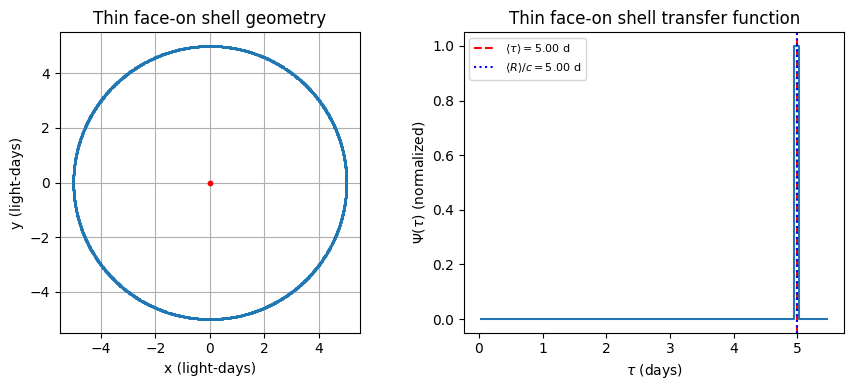

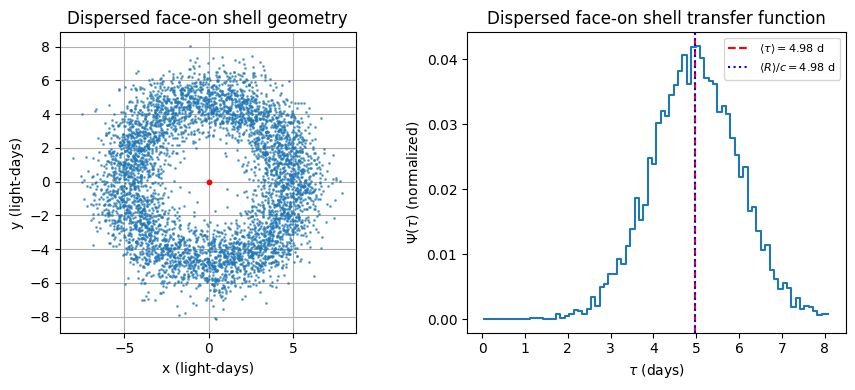

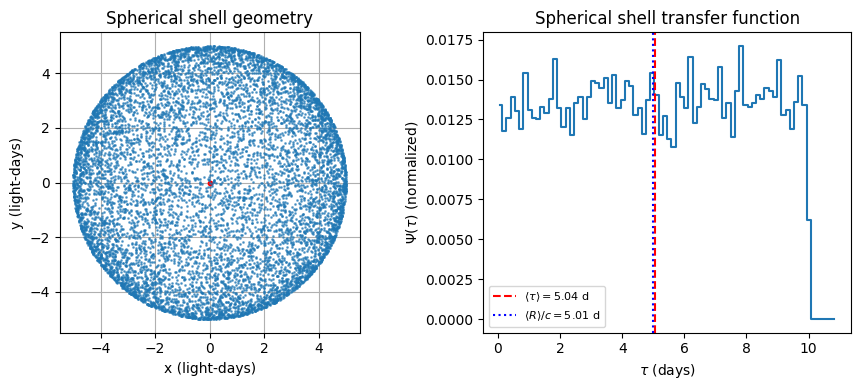

In [7]:
# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------

def plot_geometry_and_transfer(x, y, z, tau, title, nbins=80, tmax=None):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    
    # Left: geometry projected on sky (x, y)
    ax = axes[0]
    ax.grid(True, zorder=1)
    ax.scatter(0, 0, c='red', s=10, zorder=10)
    sc = ax.scatter(x, y, s=1, alpha=0.6, zorder=11)
    ax.set_xlabel("x (light-days)")
    ax.set_ylabel("y (light-days)")
    ax.set_aspect("equal", "box")
    ax.set_title(title + " geometry")
    
    # Compute mean radius and mean lag
    r = np.sqrt(x**2 + y**2 + z**2)
    mean_r = np.mean(r)
    mean_tau = np.mean(tau)
    
    # Right: 1D transfer function Psi(tau)
    t_centers, psi = transfer_function(tau, nbins=nbins, tmax=tmax)
    ax2 = axes[1]
    ax2.plot(t_centers, psi, drawstyle="steps-mid")
    # ax2.fill_between(t_centers, 0, psi)
    ax2.set_xlabel(r"$\tau$ (days)")
    ax2.set_ylabel(r"$\Psi(\tau)$ (normalized)")
    ax2.set_title(title + " transfer function")
    
    # Vertical line at mean lag
    ax2.axvline(mean_tau, color="red", linestyle="--",
                label=fr"$\langle \tau \rangle = {mean_tau:.2f}$ d")
    
    # Optional: vertical line showing mean light-travel time for mean radius
    # For a simple face-on case you might want tau_r = mean_r / c
    c = 1.0  # same units as before
    tau_r = mean_r / c
    ax2.axvline(tau_r, color="blue", linestyle=":",
                label=fr"$\langle R \rangle / c = {tau_r:.2f}$ d")
    
    ax2.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Generate and plot all five cases
# ------------------------------------------------------------

np.random.seed(42)

geometries = [
    (geometry_1_thin_ring,  "Thin face-on shell"),
    (geometry_2_thick_ring, "Dispersed face-on shell"),
    (geometry_3_spherical_shell, "Spherical shell"),
]

for geom_func, name in geometries:
    x, y, z, tau = geom_func()
    plot_geometry_and_transfer(x, y, z, tau, title=name)

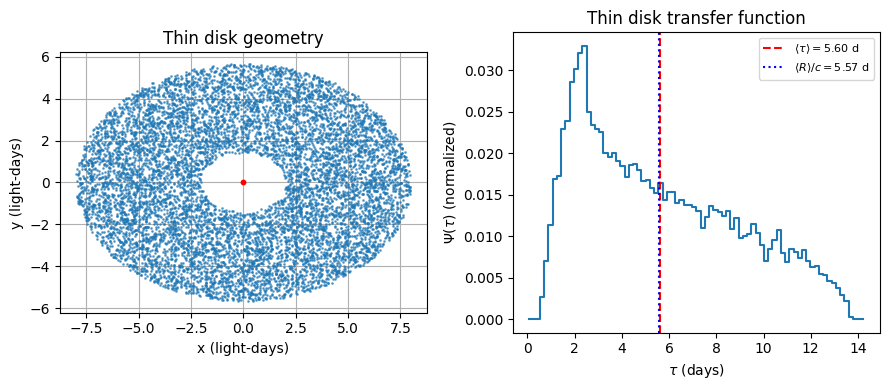

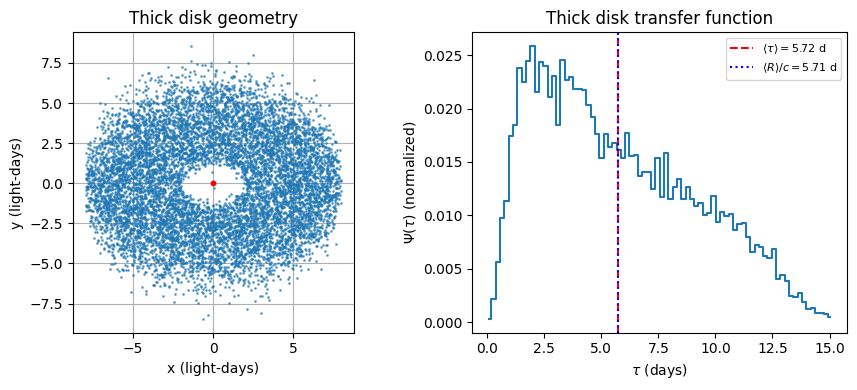

In [8]:
def geometry_1_thin_ring(N=5000, R=5.0, inc_deg=3):
    x, y, z = sample_ring(N, R)
    tau, x_rot, y_rot, z_rot = time_delays(x, y, z, inc_deg)
    return x_rot, y_rot, z_rot, tau

def geometry_2_thick_ring(N=5000, R0=5.0, sigma_R=1.0, inc_deg=30):
    x, y, z = sample_thick_ring(N, R0, sigma_R)
    tau, x_rot, y_rot, z_rot = time_delays(x, y, z, inc_deg)
    return x_rot, y_rot, z_rot, tau

bottom_inc = 45.

def geometry_4_thin_disk(N=10000, R_in=2.0, R_out=8.0, inc_deg=bottom_inc):
    x, y, z = sample_disk(N, R_in, R_out, h_over_r=0.0)
    tau, x_rot, y_rot, z_rot = time_delays(x, y, z, inc_deg)
    return x_rot, y_rot, z_rot, tau

def geometry_5_thick_disk(N=10000, R_in=2.0, R_out=8.0, inc_deg=bottom_inc, h_over_r=0.2):
    x, y, z = sample_disk(N, R_in, R_out, h_over_r=h_over_r)
    tau, x_rot, y_rot, z_rot = time_delays(x, y, z, inc_deg)
    return x_rot, y_rot, z_rot, tau

np.random.seed(42)
geometries = [
    # (geometry_1_thin_ring,  "Thin face-on shell"),
    # (geometry_2_thick_ring, "Dispersed face-on shell"),
    # (geometry_3_spherical_shell, "Spherical shell"),
    (geometry_4_thin_disk,  "Thin disk"),
    (geometry_5_thick_disk, "Thick disk"),
]

for geom_func, name in geometries:
    x, y, z, tau = geom_func()
    plot_geometry_and_transfer(x, y, z, tau, title=name)

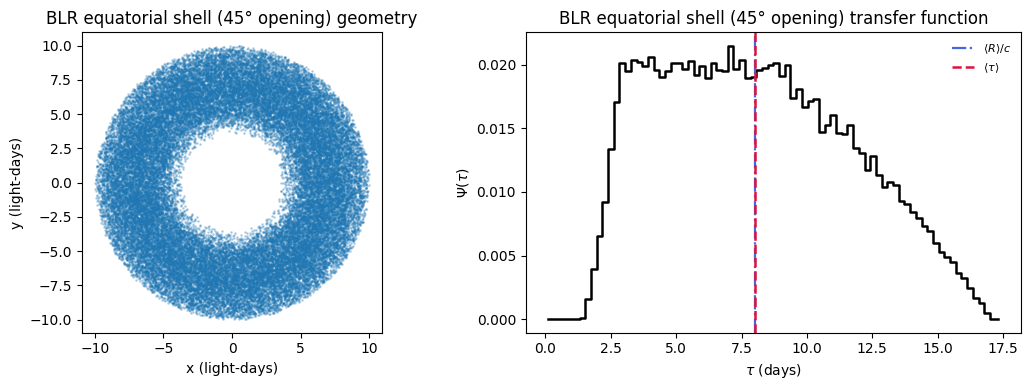

In [ ]:
def sample_blr_shell(N, R_in, R_out, opening_angle_deg, inc_deg=0.0):
    """
    BLR-style shell: full sphere truncated to +/- opening_angle_deg
    from the disk midplane (xy-plane). opening_angle_deg=90° -> full shell.
    """
    theta_o = np.deg2rad(opening_angle_deg)

    # Radial: uniform volume between R_in and R_out
    u = np.random.uniform(0, 1, N)
    r = (R_in**3 + u * (R_out**3 - R_in**3))**(1/3)

    # Azimuthal: uniform
    phi = np.random.uniform(0, 2*np.pi, N)

    # Polar angle theta: uniform between (90° - theta_o) and (90° + theta_o)
    # This puts all clouds within +/- theta_o of the equatorial plane
    cos_theta = np.random.uniform(np.cos(np.pi/2 + theta_o), np.cos(np.pi/2 - theta_o), N)
    sin_theta = np.sqrt(1 - cos_theta**2)

    x = r * sin_theta * np.cos(phi)
    y = r * sin_theta * np.sin(phi)
    z = r * cos_theta

    # Apply inclination
    tau, x2, y2, z2 = time_delays(x, y, z, inc_deg)

    return x2, y2, z2, tau

def geometry_blr_shell(N=8000, R_in=5, R_out=10., opening_angle_deg=60.0, inc_deg=0.0):
    return sample_blr_shell(N, R_in, R_out, opening_angle_deg, inc_deg)



def geometry_opening_shell(N=8000, R_in=5.0, R_out=5.01,
                           opening_angle_deg=60.0, inc_deg=45.0,
                           filled=True, both_poles=True):
    x, y, z = sample_blr_shell(N=N, R_in=R_in, R_out=R_out, opening_angle_deg=opening_angle_deg)
    tau, x2, y2, z2 = time_delays(x, y, z, inc_deg=inc_deg)
    return x2, y2, z2, tau

np.random.seed(42)

fig = plot_geometry_and_transfer(
    *geometry_blr_shell(
        N=50000,
        R_in=5.,
        R_out=10.,
        opening_angle_deg=45,  # Half-thickness from midplane
        inc_deg=0
    ),
    title='BLR equatorial shell (45° opening)'
)

plt.show()